# Fairness Audit: Telco NPS Prediction

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [ ]:
train = pd.read_csv("../data/processed/telco_nps_train.csv")
test = pd.read_csv("../data/processed/telco_nps_test.csv")

assert "NPS_baseline" not in train.columns, "NPS_baseline présente — régénérer 03_data_preparation avant de continuer"

X_train = train.drop(columns=["Customer ID", "NPS_Category"])
X_test = test.drop(columns=["Customer ID", "NPS_Category"])
y_train, y_test = train["NPS_Category"], test["NPS_Category"]

cat_cols = X_train.select_dtypes(include="str").columns.tolist()
num_cols = X_train.select_dtypes(exclude="str").columns.tolist()

In [ ]:
pipe_lr = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ])),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])
pipe_lr.fit(X_train, y_train)
pred = pd.Series(pipe_lr.predict(X_test), index=test.index)

## Detractor Recall by Demographic Subgroup

In [ ]:
def recall_by_group(col):
    out = {}
    for val in test[col].unique():
        mask = test[col] == val
        yt, yp = y_test[mask], pred[mask]
        out[f"{col}={val}"] = (yp[yt == "Detractor"] == "Detractor").mean()
    return out

results = {}
results.update(recall_by_group("SeniorCitizen"))
results.update(recall_by_group("gender"))
results.update(recall_by_group("Partner"))
results.update(recall_by_group("Dependents"))

pd.Series(results).sort_values()

Dependents=Yes     0.513889
Partner=Yes        0.646154
SeniorCitizen=0    0.664407
gender=Female      0.703704
gender=Male        0.718919
Partner=No         0.745902
Dependents=No      0.758278
SeniorCitizen=1    0.886076
dtype: float64

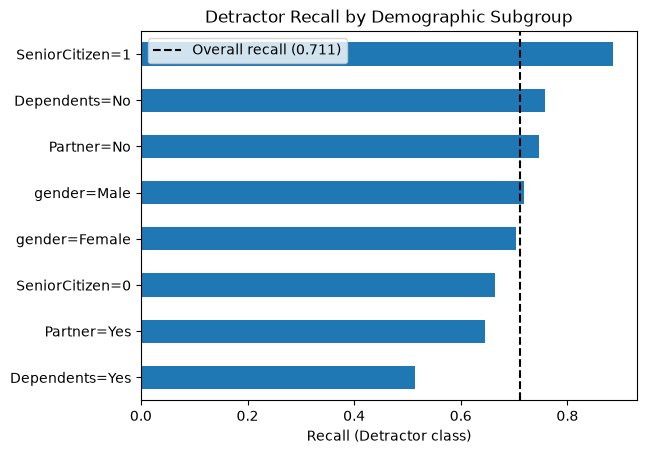

In [ ]:
pd.Series(results).sort_values().plot(kind="barh")
plt.axvline(0.711, color="black", linestyle="--", label="Overall recall (0.711)")
plt.title("Detractor Recall by Demographic Subgroup")
plt.xlabel("Recall (Detractor class)")
plt.legend()
plt.show()

Overall reminder: the Detractor class represents **71.1%** of the dataset. Two separate observations should be highlighted: one is reassuring, while the other raises a concern.

### Gender :no meaningful disparity

`gender=Female` (70.4%) and `gender=Male` (71.9%) show almost identical results — a difference of only 1.5 percentage points, which is within normal statistical variation.

There is no meaningful disparity detected for this dimension.

### SeniorCitizen: disparity exists, but opposite to the initial hypothesis

In `02_data_understanding`, we identified that senior customers had lower average satisfaction and were overrepresented among low satisfaction scores — a signal suggesting that the model might have more difficulty capturing their cases.

However, the opposite result is observed: the model captures senior detractors better (88.6%) than non-senior detractors (66.4%), with a 22-point difference in favor of senior customers.

This is not necessarily an unfairness issue, as there is no evidence that a vulnerable group is being negatively impacted. However, it is still a real and measurable disparity that should be documented. It is important to avoid drawing premature conclusions from early signals and to evaluate fairness based on model results rather than initial assumptions.

### Dependents: the most important disparity

**This is the strongest fairness signal identified in this audit.**

The Detractor recall drops to 51.4% for customers with dependents, compared to 75.8% for customers without dependents — a 24-point gap. This is similar to the type of issue described in the fairness requirement: a model that performs well for one group but significantly worse for another requires further investigation.

Almost one out of two Detractors with `Dependents=Yes` is missed by the model.

`Partner=Yes` (64.6%) shows a more moderate disparity but follows the same direction. This is consistent with the fact that `Partner` and `Dependents` are correlated variables, as they often represent similar household profiles.

## Root Cause Investigation:Dependents
 
Before drawing conclusions, we need to understand *where* the errors are concentrated, not just how many errors exist.

In [ ]:
for val in ["Yes", "No"]:
    mask = test["Dependents"] == val
    print(f"Dependents={val}")
    print(confusion_matrix(y_test[mask], pred[mask], labels=["Detractor","Passive","Promoter"]))

Dependents=Yes
[[ 37  14  21]
 [ 23 122 131]
 [  8   3  62]]
Dependents=No
[[229  20  53]
 [136 183 210]
 [ 59   2  96]]


Among the 72 true Detractors with `Dependents=Yes`, **21 are classified as Promoters** — the most severe possible error, as the prediction is completely opposite to the actual class.

This represents 29% of Detractors in this group, compared to 15.5% for `Dependents=No` (53 out of 341).

Therefore, this is not simply a case of "slightly worse performance". A disproportionate share of Detractors in this group is being actively misclassified as the opposite end of the NPS scale.

In [ ]:
test.groupby("Dependents")[["tenure","MonthlyCharges"]].mean()
pd.crosstab(test["Dependents"], test["Contract"], normalize="index") * 100

Contract,Month-to-month,One year,Two year
Dependents,,,
No,64.170040,17.510121,18.319838
Yes,40.142518,24.940618,34.916865


**Root cause hypothesis**: customers with dependents have a structurally different profile based on the two most important model features (`tenure` and `Contract`).

They are generally older customers with longer tenure and are less frequently on month-to-month contracts. The model may have learned that this profile is statistically associated with loyal customers.

As a result, a hidden Detractor within this group becomes harder to detect because the usual risk signals (new customer, month-to-month contract) are not present, even though the customer may be dissatisfied for other reasons (service quality, pricing, or overall experience) that the model does not capture as effectively.

This remains a correlation hypothesis between `Dependents` and the dominant model features, not a proven causal relationship. This interpretation follows the same cautious approach used during model interpretability analysis.

### Intersectional check (small-sample caveat)

In [ ]:
for sc in [0, 1]:
    for dep in ["Yes", "No"]:
        mask = (test["SeniorCitizen"] == sc) & (test["Dependents"] == dep)
        n_det = (y_test[mask] == "Detractor").sum()
        if n_det >= 10:
            r = (pred[mask][y_test[mask]=="Detractor"] == "Detractor").mean()
            print(f"SeniorCitizen={sc}, Dependents={dep}: recall={r:.3f} (n={n_det})")

SeniorCitizen=0, Dependents=Yes: recall=0.507 (n=69)
SeniorCitizen=0, Dependents=No: recall=0.712 (n=226)
SeniorCitizen=1, Dependents=No: recall=0.895 (n=76)


The subgroup `SeniorCitizen=1 & Dependents=Yes` is intentionally excluded: fewer than 10 Detractors exist in this combination, making any recall estimate statistically unreliable. A single prediction error could change the metric by several dozen percentage points.

**Honest limitation to document**: a more detailed intersectional fairness analysis beyond these main demographic groups is limited by the size of the test set (1,409 rows). A deeper fairness audit would require either more data or a larger dedicated test set to properly evaluate smaller intersectional groups.

## Feature Proxy Check

- **`SeniorCitizen`, `gender`, `Partner`, and `Dependents`** are directly used as features (see `04_modeling`). No hidden proxy is involved; the protected attributes are explicitly available, which makes this fairness audit possible.

- **Geography (ZIP/Lat/Long)**: not available in this project (the IBM dataset "Location" file was not used, as documented in `03_data_preparation`). It is therefore impossible to audit a potential socio-economic geographic proxy that was never included. This should be reported as a limitation of the audit rather than assuming it was covered.

- **`household_size_proxy`** (engineered feature created in `03_data_preparation`, calculated from `Partner` + `Dependents`) is actually a direct aggregation of the two demographic variables showing the strongest disparity. It does not introduce a new risk, but it inherits the existing demographic signal. If `household_size_proxy` becomes too influential in the model, removing only `Dependents` or `Partner` would not be enough to remove the underlying demographic information.

## Business Consequences & Recommendation

Removing `Dependents` from the model would reduce performance in other areas (it is one of the 25 features, not just noise). However, keeping it without any adjustment means that a retention strategy based on this model would systematically miss almost one out of two Detractors among customers with dependents.

This is not a small or irrelevant segment for a telecom operator, as these customers are often associated with family plans and potentially higher customer value.

**Concrete recommendation, not just a metric to monitor:**

1. **Do not deploy this model as-is for retention prioritization without compensation.**  
   A lower decision threshold specifically for the `Dependents=Yes` group could reduce under-targeting by identifying more potential Detractors, at the cost of generating more false positives for this segment.

2. **Escalate this issue to the Customer Experience team before production deployment.**  
   This is not only a technical problem. The decision to apply different thresholds across groups has product and potentially legal implications, as it involves differentiated treatment based indirectly on household composition. This decision should not be made by the modeling team alone.

3. **Do not address the issue only through modeling adjustments** (for example, increasing the weight of `Dependents=Yes` with `class_weight`).  
   Given the hypothesis that the issue is linked to confusion with `tenure` and `Contract`, a simple rebalancing approach could reduce performance for the majority group without solving the root problem. The model is missing discriminative signals for this customer profile, not only insufficient weighting.

## Summary — Decisions & Limitations

- **Gender**: no significant disparity was observed in Detractor recall (70.4% vs 71.9%).

- **SeniorCitizen**: a real disparity exists, but it is opposite to the initial hypothesis from `02_data_understanding`. Senior customers are captured better by the model (88.6% vs 66.4%), not worse. This result was documented honestly despite contradicting the initial assumption.

- **Dependents (and, to a lesser extent, Partner)**: a serious and actionable disparity was identified — 51.4% recall compared to 75.8%, with a much higher rate of severe errors (Detractor → Promoter) for this group. A root cause hypothesis was documented (confusion with `tenure` and `Contract`) without presenting it as a proven causal explanation.

- **Known limitation**: no geographic data was available to audit potential socio-economic proxies such as ZIP code. This constraint was documented earlier and is not a missing step in the audit.

- **Statistical limitation**: intersectional analysis (combining multiple demographic attributes) is limited by the size of the test set. One subgroup was intentionally excluded because its sample size was too small to produce reliable metrics.

- **Actionable recommendation provided**, not only a descriptive audit: escalation to the Customer Experience team and consideration of group-specific threshold adjustments, with an explicit warning against naive modeling fixes.

## Conclusion

The fairness audit reveals a real disparity, not related to gender and not in the direction initially expected for age, but mainly linked to household composition (`Dependents`). The 24-point gap in Detractor recall is significant and cannot be ignored once identified.

This is exactly the type of finding that should not be overlooked because of good overall model performance. The selected model from `05_evaluation` is statistically strong overall, but deploying it without adjustment could systematically disadvantage an identifiable customer segment.

This issue should be explicitly discussed with the Customer Experience team before any production deployment.